In [105]:
# 
# Get holdings for a fund a given preiod of report (financial quarter).
# A fund can file an initial form and subsequent amendments for a period of report .
# This script aggregates all such forms inti a final holding set.
#

In [106]:
# install forms13f python sdk 
try:
    import forms13f 
    print('forms13f forms13f package is already installed')
except ImportError:
    # Package not found, so install it from GitHub
    !pip install git+https://github.com/forms13f/python-sdk.git


forms13f forms13f package is already installed


In [107]:
from api import *
from pprint import pprint

# Find the CIK for "Berkshire Hathaway"
funds = getCIKsByName("Berkshire Hathaway")
cik = funds[0] if funds else None
print(f"CIK for Berkshire Hathaway: {cik}")

# Example usage
cik = "0001067983"  # Example CIK for Berkshire Hathaway Inc
last_period_of_report = getLastReportPeriod(cik)
print(f"Last period of report for CIK {cik}: {last_period_of_report}")

CIK for Berkshire Hathaway: 0001067983
Last period of report for CIK 0001067983: 2024-06-30


In [108]:
# Get aggregated quarter report
from pprint import pprint
from report import *
# Example usage
quarter = "2023-Q3"
cik = "0001067983"  # Example CIK for Berkshire Hathaway Inc
quarter_report = getQuarterReport(quarter, cik)
pprint(quarter_report.header.__dict__)
pprint(quarter_report.holdings)

{'accession_numbers': ['0000950123-23-010898',
                       '0000950123-23-011029',
                       '0000950123-24-005653'],
 'business_address': '3555 FARNAM STREET, OMAHA, NE, 68131',
 'business_phone': '4023461400',
 'cik': '0001067983',
 'company_name': 'BERKSHIRE HATHAWAY INC',
 'date_as_of_change': datetime.date(2023, 11, 14),
 'effectiveness_date': datetime.date(2023, 11, 14),
 'filing_dates': [datetime.date(2023, 11, 14),
                  datetime.date(2023, 11, 16),
                  datetime.date(2024, 5, 15)],
 'fiscal_year_end': '1231',
 'form_type': '13F-HR',
 'irs_number': '470813844',
 'period_of_report': datetime.date(2023, 9, 30),
 'public_document_count': 2,
 'report_quarter': '2023-Q3',
 'sec_act': '1934 Act',
 'state_of_incorporation': 'DE',
 'submission_type': '13F-HR',
 'table_entry_total': 152,
 'table_value_total': 313257308189,
 'urls': ['https://www.sec.gov/Archives/edgar/data/1067983/0000950123-23-010898.txt',
          'https://www.sec.gov/

In [109]:
from pprint import pprint
from report import *

# Define the quarters to iterate over
quarters = ['2023-Q1', '2023-Q2', '2023-Q3', '2024-Q1', '2024-Q2']

cik = "0001067983"  # Example CIK for Berkshire Hathaway Inc

# Initialize the reports array
reports = []

# Iterate over the quarters and append the reports to the array
for quarter in quarters:
    quarter_report = getQuarterReport(quarter, cik)
    reports.append(quarter_report)


In [110]:
import pandas as pd
from datetime import date
import matplotlib.pyplot as plt

# Assuming `computeDeltaPct` is already defined

# List to hold all report data
data = []

# Loop through each QuarterReport to collect data
for report in reports:
    for holding in report.holdings:
        header = report.header
        data.append({
            'cik': header.cik,
            'company_name': header.company_name,
            'period_of_report': header.period_of_report,
            'report_quarter': header.report_quarter,  # Assuming report_quarter is like '2024-Q3'
            'name_of_issuer': holding.name_of_issuer,
            'title_of_class': holding.title_of_class,
            'cusip': holding.cusip,
            'value': holding.value,
            'ssh_prnamt': holding.ssh_prnamt,
            'ssh_prnamt_type': holding.ssh_prnamt_type,
        })



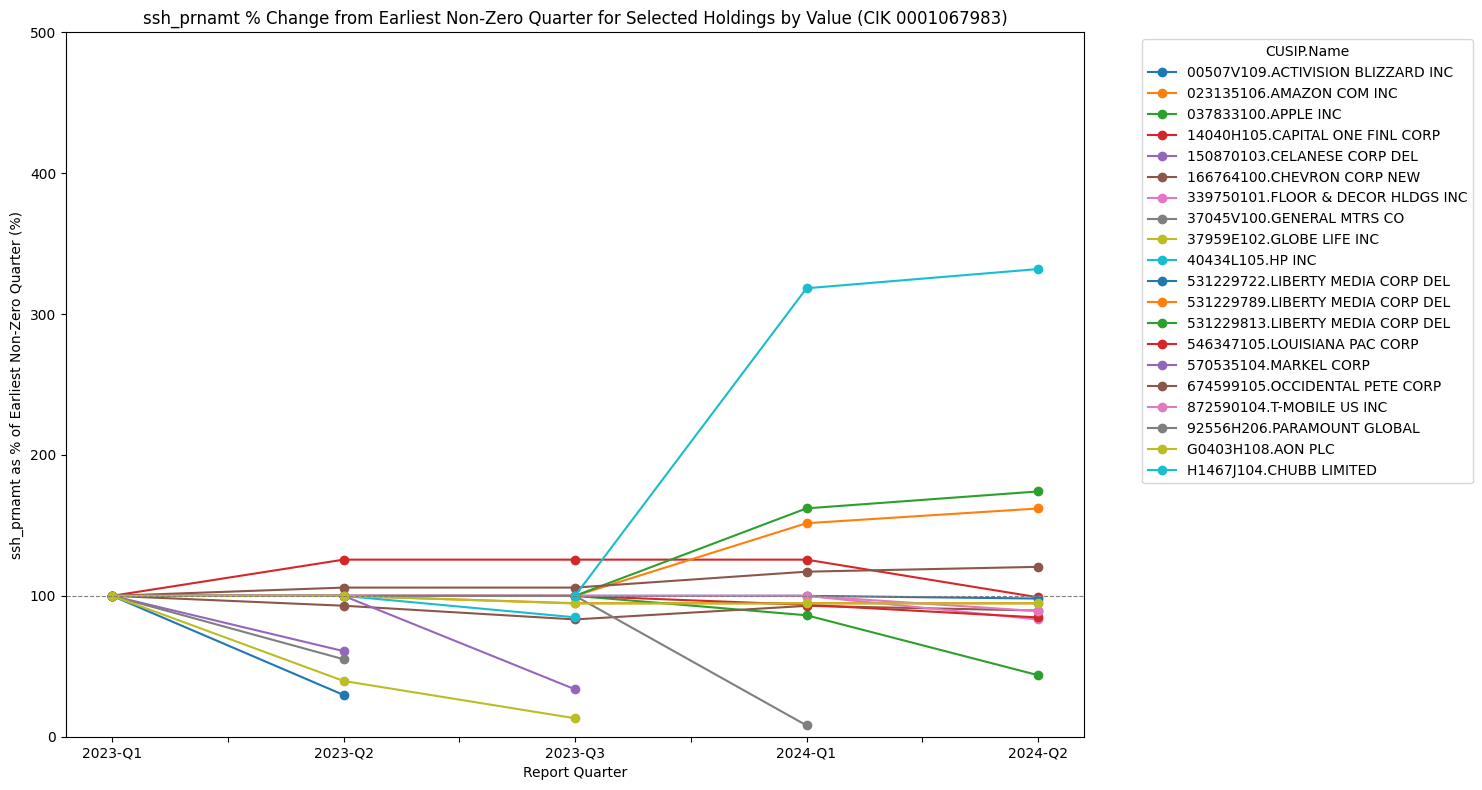

In [130]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming `data` has already been populated and the DataFrame is set up as before
df = pd.DataFrame(data)
df.set_index(['cik', 'cusip', 'report_quarter'], inplace=True)

# Calculate ssh_prnamt as a fraction of the first non-zero value for each holding in its reporting period
def first_non_zero(series):
    non_zero_values = series[series != 0]
    return non_zero_values.iloc[0] if not non_zero_values.empty else 1  # Use 1 to avoid division by zero

# Calculate the baseline percentage relative to the first non-zero value
earliest_ssh_prnamt = df.groupby(level=['cik', 'cusip'])['ssh_prnamt'].transform(first_non_zero)
df['ssh_prnamt_percent'] = (df['ssh_prnamt'] / earliest_ssh_prnamt) * 100

# Create a map from cusip to name_of_issuer
cusip_to_name_map = df.reset_index()[['cusip', 'name_of_issuer']].drop_duplicates().set_index('cusip')['name_of_issuer'].to_dict()

# Filter out holdings that did not change over all periods
df_filtered = df.groupby(level=['cik', 'cusip']).filter(lambda group: group['ssh_prnamt'].nunique() > 1)

# Define filter_on_name for specific substring matching
#filter_on_name = ["CHUBB"]  # Substring filter
filter_on_name = {}

# Apply filtering based on substring match in filter_on_name or proceed with top_n filtering
if filter_on_name:
    # Filter cusips where name_of_issuer contains any substring from filter_on_name
    cusips_to_filter = [cusip for cusip, name in cusip_to_name_map.items() if any(substring in name for substring in filter_on_name)]
    # Apply the filter to df_filtered based on the selected cusips
    df_filtered = df_filtered[df_filtered.index.get_level_values('cusip').isin(cusips_to_filter)]
else:
    # If filter_on_name is empty, proceed with top_n filtering by total value
    unique_cik_cusip_count = df_filtered.index.droplevel('report_quarter').drop_duplicates().nunique()
    top_n = min(20, unique_cik_cusip_count)
    top_cusips = df_filtered.reset_index().groupby('cusip').first().sort_values('value', ascending=False).nlargest(top_n, 'value').index
    df_filtered = df_filtered[df_filtered.index.get_level_values('cusip').isin(top_cusips)]

# Select data for the first cik
first_cik = df_filtered.index.get_level_values('cik').unique()[0]
df_first_cik = df_filtered.xs(first_cik, level='cik')

# Reset index and add 'label' with format "cusip.name_of_issuer"
df_filtered = df_first_cik.reset_index()
df_filtered['label'] = df_filtered['cusip'].map(lambda cusip: f"{cusip}.{cusip_to_name_map.get(cusip, 'Unknown')}")

# Pivot the data for plotting with cusip.name_of_issuer as columns and 'report_quarter' as rows
pivot_df = df_filtered.pivot(index='report_quarter', columns='label', values='ssh_prnamt_percent')

# Plotting
plt.figure(figsize=(15, 8))
pivot_df.plot(kind='line', marker='o', ax=plt.gca(), title=f'ssh_prnamt % Change from Earliest Non-Zero Quarter for Selected Holdings by Value (CIK {first_cik})')
plt.ylabel('ssh_prnamt as % of Earliest Non-Zero Quarter (%)')
plt.xlabel('Report Quarter')
plt.ylim(0, 500)  # Adjust y-axis limit as needed for clarity
plt.axhline(100, color='grey', linestyle='--', linewidth=0.8)  # Reference line at 100%
plt.legend(title='CUSIP.Name', bbox_to_anchor=(1.05, 1), loc='upper left')  # Position legend outside the plot
plt.tight_layout()  # Adjust layout to fit everything nicely
plt.show()
